In [1]:
# 02_clustering.ipynb

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
# 1. Cargar dataset
df = pd.read_csv("../data/historial_compras.csv")

In [3]:
# 2. Seleccionar variables para clustering
X = df[["ComprasTotales", "FrecuenciaCompras", "MontoPromedioCompra"]]

In [4]:
# 3. Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# 4. KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster_KMeans"] = kmeans.fit_predict(X_scaled)

# Evaluación KMeans
silhouette_kmeans = silhouette_score(X_scaled, df["Cluster_KMeans"])
print(f"Coeficiente de Silueta (KMeans): {silhouette_kmeans:.2f}")


Coeficiente de Silueta (KMeans): 0.38


In [6]:
# 5. DBSCAN Clustering
dbscan = DBSCAN(eps=1.2, min_samples=2)  # ajustaremos eps luego
df["Cluster_DBSCAN"] = dbscan.fit_predict(X_scaled)

# Evaluación DBSCAN (solo si hay más de 1 cluster válido)
if len(set(df["Cluster_DBSCAN"])) > 1:
    silhouette_dbscan = silhouette_score(X_scaled, df["Cluster_DBSCAN"])
    print(f"Coeficiente de Silueta (DBSCAN): {silhouette_dbscan:.2f}")
else:
    print("DBSCAN no encontró clusters válidos.")

Coeficiente de Silueta (DBSCAN): 0.53


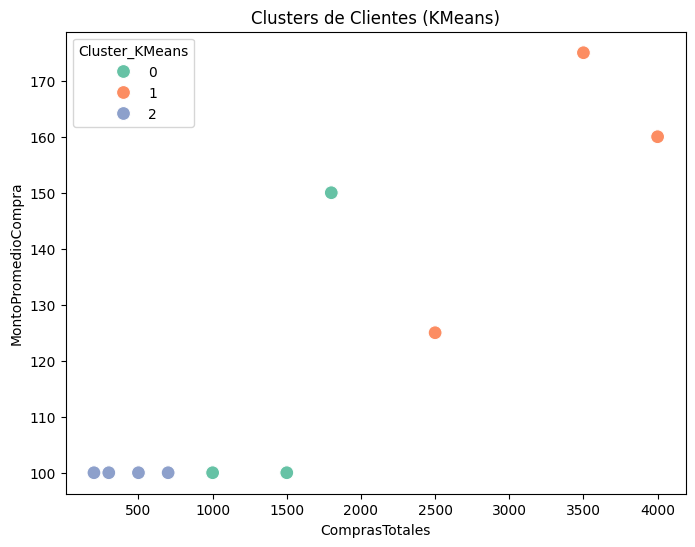

<Figure size 640x480 with 0 Axes>

In [ ]:
# 6. Visualización KMeans
plt.figure(figsize=(8,6))
sns.scatterplot(x="ComprasTotales", y="MontoPromedioCompra", 
                hue="Cluster_KMeans", data=df, palette="Set2", s=100)
plt.title("Clusters de Clientes (KMeans)")
plt.show()


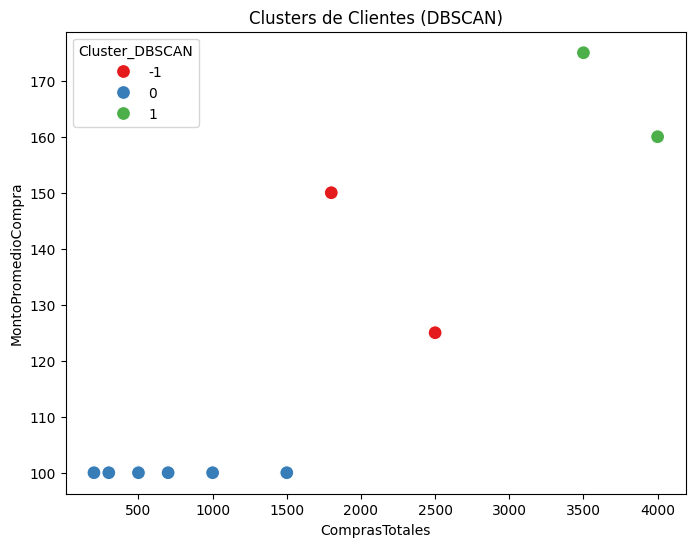

In [8]:
# 7. Visualización DBSCAN
plt.figure(figsize=(8,6))
sns.scatterplot(x="ComprasTotales", y="MontoPromedioCompra", 
                hue="Cluster_DBSCAN", data=df, palette="Set1", s=100)
plt.title("Clusters de Clientes (DBSCAN)")
plt.show()

In [9]:
# 8. Guardar resultados
df.to_csv("../resultados_IDL2/clientes_segmentados.csv", index=False)
print("Resultados guardados en resultados_IDL2/clientes_segmentados.csv")

# Mostrar resumen
print("\nCantidad de clientes por cluster (KMeans):")
print(df["Cluster_KMeans"].value_counts())

Resultados guardados en resultados_IDL2/clientes_segmentados.csv

Cantidad de clientes por cluster (KMeans):
Cluster_KMeans
2    4
0    3
1    3
Name: count, dtype: int64
